## UC-02: Smart Street & Road Lighting Design
**Authored by:** s222230275

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Pandas, Matplotlib, Working with APIs, Basic Geospatial Concepts

---

## Scenario

Urban street lighting in Melbourne runs on fixed schedules that have nothing to do with how people actually use the streets. Some streets stay brightly lit at 3am with barely anyone around, while genuinely busy spots during the evening are under-lit and not particularly safe.

In this use case, I built a preliminary pipeline that combines two real Melbourne Open Data datasets to identify where the current lighting doesn't match foot traffic, and to generate a basic streetlight placement recommendation for a given street. This is a baseline system at this stage, with LLM integration planned as the next phase.

---

## User Story

As a city planner or urban infrastructure designer, I want to receive streetlight placement recommendations based on real pedestrian activity data, so that I can design lighting systems that improve public safety and reduce wasted energy across Melbourne's streets and roads.

---

## Project Progress (Week 5 to 6)

The data pipeline is fully working at this point. Both datasets are loading cleanly, coordinates have been extracted, and pedestrian sensors are matched to their nearest streetlight using k-Nearest Neighbours. The preliminary efficiency analysis is done and the rule-based recommendation engine is producing structured outputs.

The intelligence layer is still in progress. The next phase is connecting the recommendation engine to an LLM so the outputs include richer, more context-aware explanations rather than the current templated text.

---

## What This Use Case Will Teach You

- How to load real open datasets from Melbourne Open Data using API calls
- How to clean and merge pedestrian and streetlight data from multiple sources
- How to extract GPS coordinates and use them for spatial analysis
- How to identify lighting inefficiencies using nearest neighbour matching
- How to build a baseline recommendation engine that generates lighting design proposals from real data


---
## Step 1: Imports and Setup

First I imported the libraries needed for this project. The main ones are `pandas` for data handling, `matplotlib` for charts, `sklearn` for the spatial matching, and `requests` to pull data directly from the Melbourne Open Data API.


In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import warnings
from io import StringIO
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')

# This function loads a dataset from the Melbourne Open Data portal.
# It builds the URL using the dataset name, sends a GET request, and returns a DataFrame.
# Using CSV format with semicolon separator — that's just how this API returns the data.
def load_dataset(dataset_name, limit=5000):
    base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/' + dataset_name + '/exports/csv'
    params = {'limit': limit, 'format': 'csv'}
    try:
        response = requests.get(base_url, params=params, timeout=30)
        if response.status_code == 200:
            return pd.read_csv(StringIO(response.content.decode('utf-8')), sep=';')
        else:
            print('API call failed, status:', response.status_code)
            return None
    except Exception as e:
        print('Error:', e)
        return None

# Load both datasets
pedestrian_data = load_dataset('pedestrian-counting-system-monthly-counts-per-hour')
streetlight_data = load_dataset('street-lights-with-emitted-lux-level-council-owned-lights-only')

print('Pedestrian data loaded:', pedestrian_data.shape)
print('Streetlight data loaded:', streetlight_data.shape)


Pedestrian data loaded: (5000, 9)
Streetlight data loaded: (5000, 21)


---
## Step 2: Preview the Data

Before doing anything, I check what columns are available in both datasets.


In [2]:
pedestrian_data.head()


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,75520241225,75,2024-12-25,5,2,2,4,SprFli_T,"-37.81515276, 144.97467661"
1,751320250706,75,2025-07-06,13,109,96,205,SprFli_T,"-37.81515276, 144.97467661"
2,712320240914,71,2024-09-14,23,2,1,3,WestWP_T,"-37.81235775, 144.97136962"
3,711420260125,71,2026-01-25,14,4,3,7,WestWP_T,"-37.81235775, 144.97136962"
4,711420260211,71,2026-02-11,14,4,10,14,WestWP_T,"-37.81235775, 144.97136962"


In [3]:
streetlight_data.head()


,geo_point_2d,geo_shape,prop_id,name,addresspt1,xorg,ext_id,asset_clas,label,asset_type,...,northing,str_id,addresspt,asset_subt,xsource,profile,xdate,xdrawing,mcc_id,roadseg_id
0,"-37.81383600004095, 144.94229199974288","{""coordinates"": [144.94229199974288, -37.81383...",0,NaN,0.0,ESG,280,NaN,62.659,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
1,"-37.81344200000782, 144.94172699995684","{""coordinates"": [144.94172699995684, -37.81344...",0,NaN,0.0,ESG,32,NaN,26.784,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
2,"-37.813460000022296, 144.94173700057334","{""coordinates"": [144.94173700057334, -37.81346...",0,NaN,0.0,ESG,40,NaN,25.024,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
3,"-37.81409100003984, 144.94275500001876","{""coordinates"": [144.94275500001876, -37.81409...",0,NaN,0.0,ESG,462,NaN,99.316,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
4,"-37.80229899976622, 144.96595599992463","{""coordinates"": [144.96595599992463, -37.80229...",0,NaN,0.0,ESG,550,NaN,0.587,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0


---
## Step 3: Column Overview and Missing Values

Checking the column names and missing values upfront makes the cleaning step a lot easier to plan.


In [4]:
print('Pedestrian columns:', pedestrian_data.columns.tolist())
print('\nStreetlight columns:', streetlight_data.columns.tolist())


Pedestrian columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']

Streetlight columns: ['geo_point_2d', 'geo_shape', 'prop_id', 'name', 'addresspt1', 'xorg', 'ext_id', 'asset_clas', 'label', 'asset_type', 'easting', 'northing', 'str_id', 'addresspt', 'asset_subt', 'xsource', 'profile', 'xdate', 'xdrawing', 'mcc_id', 'roadseg_id']


In [5]:
print('Pedestrian missing values:\n', pedestrian_data.isnull().sum())
print('\nStreetlight missing values:\n', streetlight_data.isnull().sum())


Pedestrian missing values:
 id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
location           0
dtype: int64

Streetlight missing values:
 geo_point_2d       0
geo_shape          0
prop_id            0
name            5000
addresspt1         0
xorg               0
ext_id             0
asset_clas      5000
label              0
asset_type      5000
easting            0
northing           0
str_id             0
addresspt          0
asset_subt      5000
xsource         5000
profile         5000
xdate              0
xdrawing        5000
mcc_id             0
roadseg_id         0
dtype: int64


---
## Step 4: Data Cleaning

### Cleaning the Streetlight Dataset

The streetlight dataset has several columns that are entirely empty, like `name`, `asset_clas`, `asset_type`, and `asset_subt`. These are asset management fields that aren't useful here, so I drop them. The key column I need is `label`, which holds the lux (brightness) rating of each light.


In [6]:
# Drop columns that are completely empty or not relevant to our analysis
cols_to_drop = ['name', 'asset_clas', 'asset_type', 'asset_subt']
cols_to_drop = [c for c in cols_to_drop if c in streetlight_data.columns]
streetlight_clean = streetlight_data.drop(columns=cols_to_drop)
streetlight_clean = streetlight_clean.dropna(subset=['geo_point_2d'])

# Convert the lux column to numeric (it sometimes loads as a string)
streetlight_clean['label'] = pd.to_numeric(streetlight_clean['label'], errors='coerce')
streetlight_clean = streetlight_clean.dropna(subset=['label'])

print('Streetlight records after cleaning:', len(streetlight_clean))
streetlight_clean.head()


Streetlight records after cleaning: 5000


,geo_point_2d,geo_shape,prop_id,addresspt1,xorg,ext_id,label,easting,northing,str_id,addresspt,xsource,profile,xdate,xdrawing,mcc_id,roadseg_id
0,"-37.81383600004095, 144.94229199974288","{""coordinates"": [144.94229199974288, -37.81383...",0,0.0,ESG,280,62.659,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0
1,"-37.81344200000782, 144.94172699995684","{""coordinates"": [144.94172699995684, -37.81344...",0,0.0,ESG,32,26.784,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0
2,"-37.813460000022296, 144.94173700057334","{""coordinates"": [144.94173700057334, -37.81346...",0,0.0,ESG,40,25.024,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0
3,"-37.81409100003984, 144.94275500001876","{""coordinates"": [144.94275500001876, -37.81409...",0,0.0,ESG,462,99.316,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0
4,"-37.80229899976622, 144.96595599992463","{""coordinates"": [144.96595599992463, -37.80229...",0,0.0,ESG,550,0.587,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0


### Cleaning the Pedestrian Dataset

For the pedestrian data, the main cleaning steps are removing rows with missing location or count values, filtering out negative pedestrian counts (which are sensor errors), parsing the date column to a proper datetime type, and adding a `total_foot_traffic` column that combines both directional counts. I also classify each reading into a time period based on the hour. The four periods are Morning, Daytime, Evening, and Night, since lighting needs vary quite a bit across the day.


In [7]:
print('Pedestrian records before cleaning:', len(pedestrian_data))

ped_clean = pedestrian_data.dropna(subset=['location', 'pedestriancount']).copy()
ped_clean = ped_clean[ped_clean['pedestriancount'] >= 0]
ped_clean['sensing_date'] = pd.to_datetime(ped_clean['sensing_date'], errors='coerce')
ped_clean = ped_clean.dropna(subset=['sensing_date'])

# Combine both directional counts into a single foot traffic figure
ped_clean['total_foot_traffic'] = ped_clean['direction_1'] + ped_clean['direction_2']

# Classify by time of day as this is important for lighting decisions
def classify_time_period(hour):
    if 6 <= hour <= 9:
        return 'Morning'
    elif 17 <= hour <= 20:
        return 'Evening'
    elif hour >= 21 or hour <= 5:
        return 'Night'
    else:
        return 'Daytime'

ped_clean['time_period'] = ped_clean['hourday'].apply(classify_time_period)

print('Pedestrian records after cleaning:', len(ped_clean))
print('\nTime period distribution:')
print(ped_clean['time_period'].value_counts())
ped_clean.head()


Pedestrian records before cleaning: 5000
Pedestrian records after cleaning: 5000

Time period distribution:
time_period
Night      1716
Daytime    1542
Morning     873
Evening     869
Name: count, dtype: int64


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,total_foot_traffic,time_period
0,75520241225,75,2024-12-25,5,2,2,4,SprFli_T,"-37.81515276, 144.97467661",4,Night
1,751320250706,75,2025-07-06,13,109,96,205,SprFli_T,"-37.81515276, 144.97467661",205,Daytime
2,712320240914,71,2024-09-14,23,2,1,3,WestWP_T,"-37.81235775, 144.97136962",3,Night
3,711420260125,71,2026-01-25,14,4,3,7,WestWP_T,"-37.81235775, 144.97136962",7,Daytime
4,711420260211,71,2026-02-11,14,4,10,14,WestWP_T,"-37.81235775, 144.97136962",14,Daytime


---
## Step 5: Extract GPS Coordinates

Both datasets store location as a single string like `-37.813, 144.969`. I need to split these into separate latitude and longitude columns before any spatial analysis can happen.


In [8]:
# Split the location string into separate lat/lon columns
ped_split = ped_clean['location'].str.strip().str.split(',', expand=True)
ped_clean['Latitude'] = pd.to_numeric(ped_split[0].str.strip(), errors='coerce')
ped_clean['Longitude'] = pd.to_numeric(ped_split[1].str.strip(), errors='coerce')
ped_clean = ped_clean.dropna(subset=['Latitude', 'Longitude'])

sl_split = streetlight_clean['geo_point_2d'].str.strip().str.split(',', expand=True)
streetlight_clean = streetlight_clean.copy()
streetlight_clean['Latitude'] = pd.to_numeric(sl_split[0].str.strip(), errors='coerce')
streetlight_clean['Longitude'] = pd.to_numeric(sl_split[1].str.strip(), errors='coerce')
streetlight_clean = streetlight_clean.dropna(subset=['Latitude', 'Longitude'])

print('Pedestrian coordinate sample:')
print(ped_clean[['Latitude', 'Longitude']].head())
print('\nStreetlight coordinate sample:')
print(streetlight_clean[['Latitude', 'Longitude']].head())


Pedestrian coordinate sample:
    Latitude   Longitude
0 -37.815153  144.974677
1 -37.815153  144.974677
2 -37.812358  144.971370
3 -37.812358  144.971370
4 -37.812358  144.971370

Streetlight coordinate sample:
    Latitude   Longitude
0 -37.813836  144.942292
1 -37.813442  144.941727
2 -37.813460  144.941737
3 -37.814091  144.942755
4 -37.802299  144.965956


---
## Step 6: Matching Pedestrian Sensors to Nearest Streetlights

Here I connect the two datasets spatially. For each pedestrian sensor, I find the single closest streetlight using k-Nearest Neighbours with k=1. This lets me compare how bright the nearest light is against how many people are actually walking past it, which is the core of the efficiency analysis.


In [9]:
ped_coords   = ped_clean[['Latitude', 'Longitude']].to_numpy()
light_coords = streetlight_clean[['Latitude', 'Longitude']].to_numpy()

# Fit the kNN model on streetlight coordinates, then find nearest light for each sensor
nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(light_coords)
distances, indices = nbrs.kneighbors(ped_coords)

ped_clean['Nearest_Light_Index'] = indices.flatten()
ped_clean['Distance_to_Light']   = distances.flatten()
ped_clean['Nearest_Light_Lux']   = ped_clean['Nearest_Light_Index'].apply(
    lambda i: streetlight_clean.iloc[i]['label']
)

print('Distances to nearest streetlight (first 5):')
print(distances[:5])
ped_clean[['sensor_name', 'total_foot_traffic', 'Nearest_Light_Lux', 'Distance_to_Light']].head()


Distances to nearest streetlight (first 5):
[[0.00050165]
 [0.00050165]
 [0.00182759]
 [0.00182759]
 [0.00182759]]


,sensor_name,total_foot_traffic,Nearest_Light_Lux,Distance_to_Light
0,SprFli_T,4,7.918,0.000502
1,SprFli_T,205,7.918,0.000502
2,WestWP_T,3,18.866,0.001828
3,WestWP_T,7,18.866,0.001828
4,WestWP_T,14,18.866,0.001828


---
## Step 7: Identifying Lighting Inefficiencies

With each sensor linked to its nearest light, I can flag two types of mismatches. The first is overlit areas with low traffic, where lux is above 50 but fewer than 100 pedestrians pass per hour, which represents wasted energy. The second is underlit areas with high traffic, where more than 500 pedestrians pass per hour but the nearest light is below 10 lux, which is a safety concern.


In [10]:
over_lit = ped_clean[
    (ped_clean['total_foot_traffic'] < 100) & (ped_clean['Nearest_Light_Lux'] > 50)
].sort_values('Nearest_Light_Lux', ascending=False)

under_lit = ped_clean[
    (ped_clean['total_foot_traffic'] > 500) & (ped_clean['Nearest_Light_Lux'] < 10)
].sort_values('total_foot_traffic', ascending=False)

print('Over-lit and low foot traffic:')
print(over_lit[['sensor_name', 'total_foot_traffic', 'Nearest_Light_Lux']].head())
print('\nUnder-lit and high foot traffic:')
print(under_lit[['sensor_name', 'total_foot_traffic', 'Nearest_Light_Lux']].head())


Over-lit and low foot traffic:
     sensor_name  total_foot_traffic  Nearest_Light_Lux
46        RMIT_T                  52             99.316
3215      RMIT_T                  34             99.316
882       RMIT_T                   9             99.316
4472      RMIT_T                  28             99.316
2424      RMIT_T                  25             99.316

Under-lit and high foot traffic:
       sensor_name  total_foot_traffic  Nearest_Light_Lux
4173        NewQ_T                4951              6.452
4995  BirFed1120_T                4362              9.286
1677      SouthB_T                3635              9.189
4361        MCEC_T                3428              2.639
2843      SouthB_T                3130              9.189


---
## Step 8: Visualising Foot Traffic vs Brightness

This scatter plot shows the relationship between pedestrian activity and the brightness of the nearest streetlight. Ideally you'd see higher lux where there are more people, but the spread here shows that's often not the case.


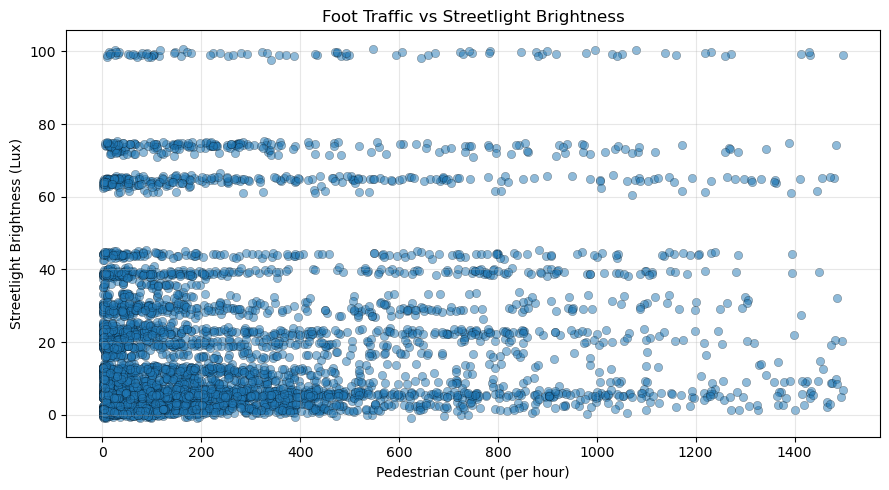

In [11]:
filtered = ped_clean[ped_clean['total_foot_traffic'] < 1500].copy()
jittered_lux = filtered['Nearest_Light_Lux'] + np.random.normal(0, 0.5, size=len(filtered))

plt.figure(figsize=(9, 5))
plt.scatter(filtered['total_foot_traffic'], jittered_lux, alpha=0.5, edgecolors='k', linewidth=0.3)
plt.xlabel('Pedestrian Count (per hour)')
plt.ylabel('Streetlight Brightness (Lux)')
plt.title('Foot Traffic vs Streetlight Brightness')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Step 9: Time-Based Pedestrian Analysis

Understanding when people are on the streets is important for smart lighting design. The charts below show average foot traffic across the hours of the day and broken down by time period.


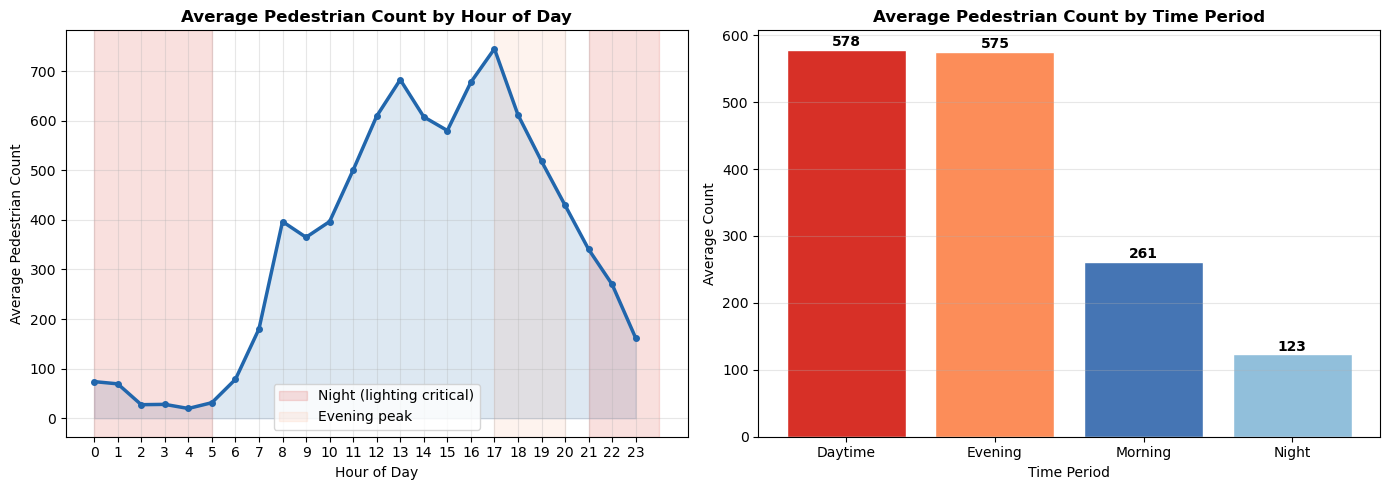

In [12]:
hourly_avg = ped_clean.groupby('hourday')['pedestriancount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_avg.index, hourly_avg.values, color='#2166ac', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='#2166ac')
axes[0].axvspan(21, 24, alpha=0.15, color='#d73027', label='Night (lighting critical)')
axes[0].axvspan(0, 5, alpha=0.15, color='#d73027')
axes[0].axvspan(17, 20, alpha=0.1, color='#fc8d59', label='Evening peak')
axes[0].set_title('Average Pedestrian Count by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Pedestrian Count')
axes[0].set_xticks(range(0, 24))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

period_avg = ped_clean.groupby('time_period')['pedestriancount'].mean().sort_values(ascending=False)
colours = ['#d73027', '#fc8d59', '#4575b4', '#91bfdb']
bars = axes[1].bar(period_avg.index, period_avg.values, color=colours[:len(period_avg)], edgecolor='white')
axes[1].set_title('Average Pedestrian Count by Time Period', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Period')
axes[1].set_ylabel('Average Count')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, period_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


---
## Step 10: Calculating Suggested Lux Levels

Based on pedestrian activity at each sensor, I calculate what lux level would be appropriate and compare it to what the nearest light actually provides. A positive difference means the area is underlit and a negative difference means it's overlit.


In [13]:
def suggest_lux(foot_traffic):
    if foot_traffic < 50:
        return 20
    elif foot_traffic < 300:
        return 40
    else:
        return 70

ped_clean['Suggested_Lux'] = ped_clean['total_foot_traffic'].apply(suggest_lux)
ped_clean['Lux_Difference'] = ped_clean['Suggested_Lux'] - ped_clean['Nearest_Light_Lux']

ped_clean[['sensor_name', 'total_foot_traffic', 'Nearest_Light_Lux', 'Suggested_Lux', 'Lux_Difference']].head()


,sensor_name,total_foot_traffic,Nearest_Light_Lux,Suggested_Lux,Lux_Difference
0,SprFli_T,4,7.918,20,12.082
1,SprFli_T,205,7.918,40,32.082
2,WestWP_T,3,18.866,20,1.134
3,WestWP_T,7,18.866,20,1.134
4,WestWP_T,14,18.866,20,1.134


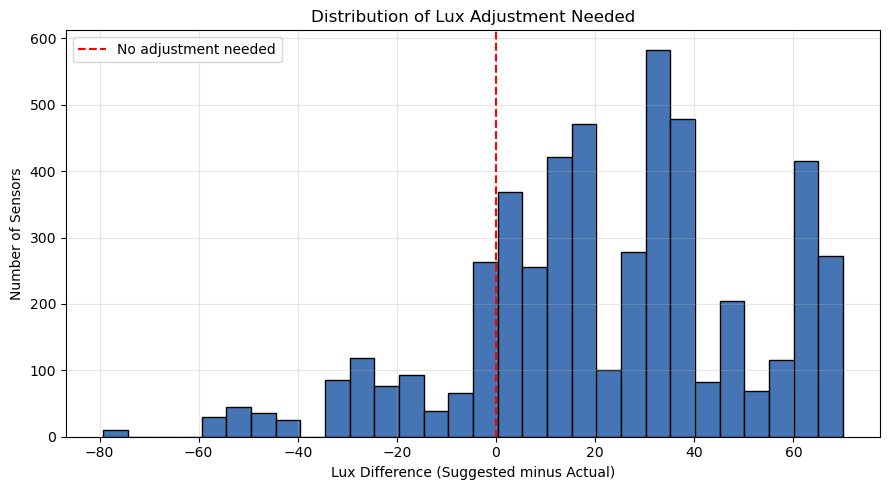

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(ped_clean['Lux_Difference'], bins=30, edgecolor='black', color='#4575b4')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No adjustment needed')
plt.title('Distribution of Lux Adjustment Needed')
plt.xlabel('Lux Difference (Suggested minus Actual)')
plt.ylabel('Number of Sensors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Step 11: Efficiency Classification

I classify each sensor location into one of three categories so city planners can quickly see where action is needed. Efficient means the foot traffic and lux are reasonably matched. Underlit means high traffic but not enough light, which is a safety risk. Overlit means low traffic but too much light, which is an energy-saving opportunity.


Efficiency category distribution:
efficiency_category
Underlit         2056
Efficient        1509
Uncategorised     966
Overlit           469
Name: count, dtype: int64


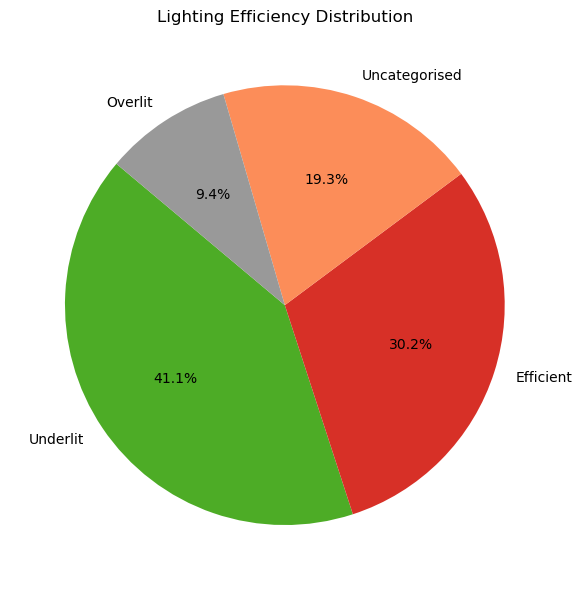

In [15]:
lux_threshold     = 20
traffic_threshold = 50

conditions = [
    (ped_clean['pedestriancount'] >= traffic_threshold) & (ped_clean['Nearest_Light_Lux'] >= lux_threshold),
    (ped_clean['pedestriancount'] >= traffic_threshold) & (ped_clean['Nearest_Light_Lux'] <  lux_threshold),
    (ped_clean['pedestriancount'] <  traffic_threshold) & (ped_clean['Nearest_Light_Lux'] >= lux_threshold)
]
choices = ['Efficient', 'Underlit', 'Overlit']
ped_clean['efficiency_category'] = np.select(conditions, choices, default='Uncategorised')

print('Efficiency category distribution:')
print(ped_clean['efficiency_category'].value_counts())

eff_counts = ped_clean['efficiency_category'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(eff_counts, labels=eff_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#4dac26', '#d73027', '#fc8d59', '#999999'])
plt.title('Lighting Efficiency Distribution')
plt.tight_layout()
plt.show()


---
## Step 12: Exploratory Analysis, Clustering Pedestrian Zones

As an extra exploratory step, I used K-Means clustering to group sensor locations into spatial zones. This isn't part of the core pipeline yet. It's more of an experiment to see if the data naturally groups into different activity areas. In a later version, these zone profiles could be used to drive adaptive dimming schedules.


Zone summary:
      total_foot_traffic  Lux_Difference
Zone                                    
0                  480.4            28.0
1                  124.6            14.7
2                  366.4            16.2
3                  327.2            24.8
4                   72.3            27.1


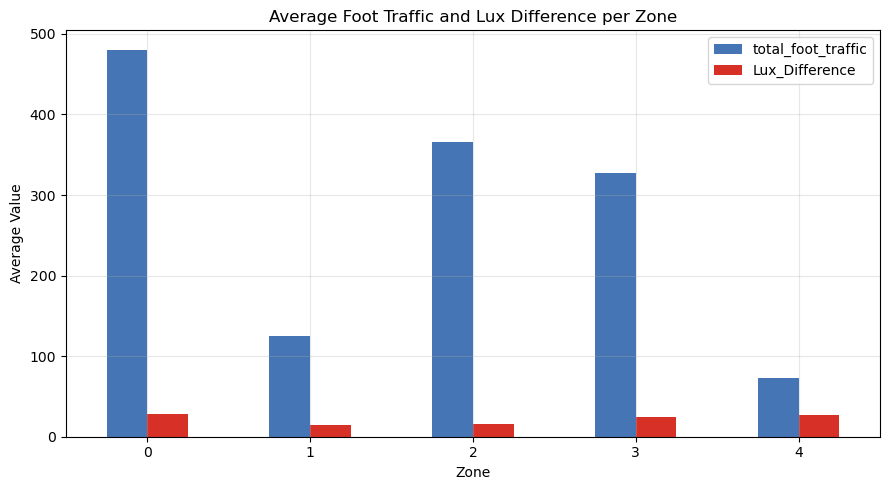

In [16]:
coords = ped_clean[['Latitude', 'Longitude']]
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10).fit(coords)
ped_clean['Zone'] = kmeans.labels_

zone_summary = ped_clean.groupby('Zone')[['total_foot_traffic', 'Lux_Difference']].mean().round(1)
print('Zone summary:')
print(zone_summary)

zone_summary.plot(kind='bar', figsize=(9, 5),
                  title='Average Foot Traffic and Lux Difference per Zone',
                  color=['#4575b4', '#d73027'])
plt.xlabel('Zone')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# Rough lighting profiles based on the zone activity levels
# These are placeholders for now, will be refined with more data
zone_profiles = {
    0: 'Commute-based Lighting (Bright 7-9AM and 5-7PM)',
    1: 'Retail Zone (Bright 11AM-4PM)',
    2: 'Consistent Lighting (Low-level always on)',
    3: 'Dimmed Zone (Motion-triggered only)',
    4: 'Adaptive Lighting (Responsive to real-time sensor data)'
}

profile_df = pd.DataFrame.from_dict(zone_profiles, orient='index', columns=['Lighting Strategy'])
profile_df.index.name = 'Zone'
profile_df.reset_index()


,Zone,Lighting Strategy
0,0,Commute-based Lighting (Bright 7-9AM and 5-7PM)
1,1,Retail Zone (Bright 11AM-4PM)
2,2,Consistent Lighting (Low-level always on)
3,3,Dimmed Zone (Motion-triggered only)
4,4,Adaptive Lighting (Responsive to real-time sen...


---
## Step 13: Efficiency Map

Plotting sensor locations coloured by efficiency category gives a geographic view of where lighting needs attention across Melbourne CBD. Green sensors are efficient, red ones are underlit and represent safety concerns, and orange ones are overlit and represent energy-saving opportunities.


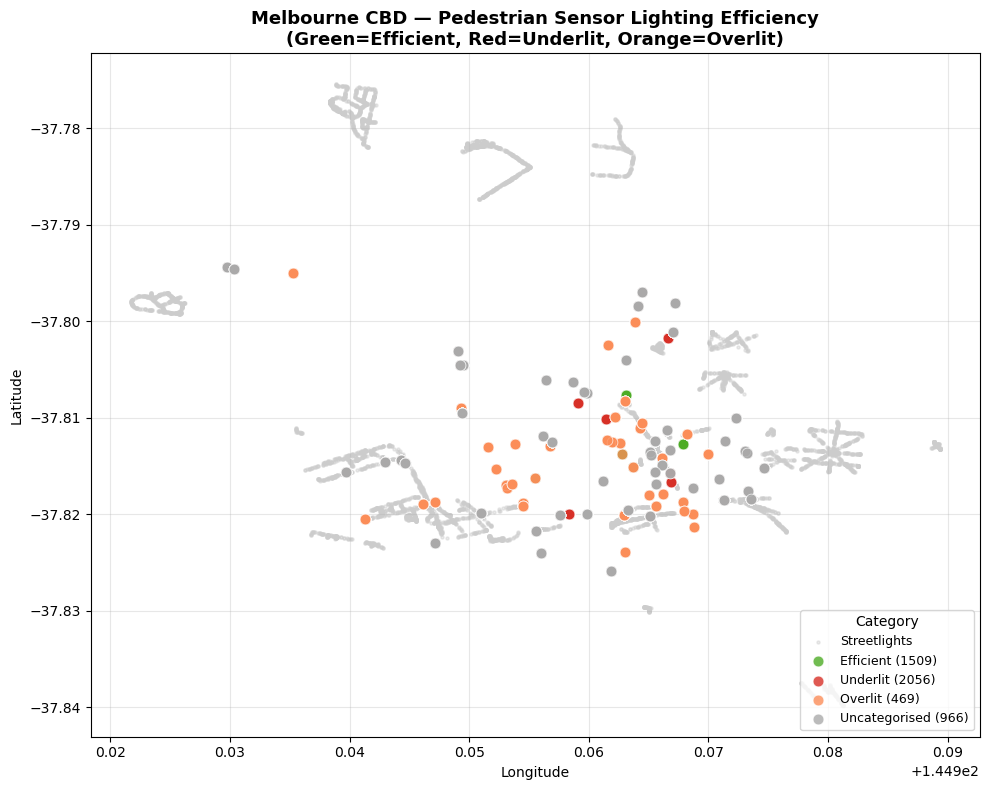

Map saved as lighting_efficiency_map.png


In [18]:
colour_map = {'Efficient': '#4dac26', 'Underlit': '#d73027', 'Overlit': '#fc8d59', 'Uncategorised': '#aaaaaa'}

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(streetlight_clean['Longitude'], streetlight_clean['Latitude'],
           c='#cccccc', s=5, alpha=0.4, label='Streetlights', zorder=1)

for category, colour in colour_map.items():
    subset = ped_clean[ped_clean['efficiency_category'] == category]
    if len(subset) > 0:
        ax.scatter(subset['Longitude'], subset['Latitude'],
                   c=colour, label=f'{category} ({len(subset)})',
                   s=60, alpha=0.8, edgecolors='white', linewidth=0.5, zorder=3)

ax.set_title('Melbourne CBD — Pedestrian Sensor Lighting Efficiency\n(Green=Efficient, Red=Underlit, Orange=Overlit)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Category', fontsize=9, title_fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lighting_efficiency_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Map saved as lighting_efficiency_map.png')


---
## Step 14: Lighting Recommendation Logic

This function calculates a preliminary streetlight layout for a given street based on its length and activity level. It works out the number of lights needed, the spacing between them, the recommended technology, and an estimated yearly energy cost.

For the energy model I assumed lights run for roughly 10 hours per night, which is a reasonable dusk to dawn average for Melbourne, and used $0.25 AUD per kWh as a typical commercial electricity rate. This is a rough estimate for comparing streets rather than a precise billing calculation.


In [19]:
def calculate_lighting_recommendation(street_length_m, activity_level):
    spacing_rules = {'High': 20, 'Medium': 30, 'Low': 40}
    tech_rules    = {'High': 'LED (high output, 150W)', 'Medium': 'LED (standard, 80W)', 'Low': 'LED Solar (40W)'}
    wattage       = {'High': 150, 'Medium': 80, 'Low': 40}

    spacing     = spacing_rules.get(activity_level, 30)
    num_lights  = max(2, round(street_length_m / spacing))
    watts       = wattage.get(activity_level, 80)
    yearly_kwh  = (num_lights * watts * 10 * 365) / 1000
    yearly_cost = round(yearly_kwh * 0.25, 2)

    return {
        'street_length_m':   round(street_length_m, 1),
        'activity_level':    activity_level,
        'num_lights':        num_lights,
        'spacing_m':         spacing,
        'technology':        tech_rules.get(activity_level),
        'wattage_per_light': watts,
        'yearly_energy_kwh': round(yearly_kwh, 1),
        'yearly_cost_aud':   yearly_cost
    }

# Test it with a few examples
print('=== Example Lighting Recommendations ===')
for length, level in [(300, 'High'), (200, 'Medium'), (150, 'Low')]:
    rec = calculate_lighting_recommendation(length, level)
    print(f'\n{length}m street, {level} activity:')
    for k, v in rec.items():
        print(f'  {k}: {v}')


=== Example Lighting Recommendations ===

300m street, High activity:
  street_length_m: 300
  activity_level: High
  num_lights: 15
  spacing_m: 20
  technology: LED (high output, 150W)
  wattage_per_light: 150
  yearly_energy_kwh: 8212.5
  yearly_cost_aud: 2053.12

200m street, Medium activity:
  street_length_m: 200
  activity_level: Medium
  num_lights: 7
  spacing_m: 30
  technology: LED (standard, 80W)
  wattage_per_light: 80
  yearly_energy_kwh: 2044.0
  yearly_cost_aud: 511.0

150m street, Low activity:
  street_length_m: 150
  activity_level: Low
  num_lights: 4
  spacing_m: 40
  technology: LED Solar (40W)
  wattage_per_light: 40
  yearly_energy_kwh: 584.0
  yearly_cost_aud: 146.0


---
## Step 15: Rule-Based Recommendation Generator

This function takes the street data and calculated parameters and builds a structured recommendation report. It's rule-based for now, which is fine for this stage of the project. The plan is to replace this with an LLM call in the next phase so the explanations are more dynamic and can reference actual lighting standards.


In [20]:
def generate_lighting_recommendation(street_name, street_length_m, activity_level,
                                      morning_avg, evening_avg, night_avg):
    rec = calculate_lighting_recommendation(street_length_m, activity_level)

    # Work out when the busiest period is
    peak_period = 'evening' if evening_avg >= morning_avg else 'morning'
    peak_count  = max(morning_avg, evening_avg)

    # Spacing justification based on activity
    spacing_reason = {
        'High':   'The high pedestrian volume requires closer spacing to maintain safe, consistent illumination.',
        'Medium': 'Moderate foot traffic supports standard spacing, balancing coverage and energy use.',
        'Low':    'Low pedestrian activity allows wider spacing, reducing installation and running costs.'
    }.get(activity_level, '')

    # Check if adaptive dimming at night makes sense
    if night_avg < morning_avg * 0.3:
        dimming_note = ('Night pedestrian counts are significantly lower than peak periods. '
                        'Adaptive dimming after 10pm could reduce energy costs by around 20-30%% '
                        'without compromising safety.')
    else:
        dimming_note = ('Night pedestrian activity remains relatively high. '
                        'Full illumination is recommended throughout the night period.')

    report = f"""
=== LIGHTING DESIGN RECOMMENDATION ===
Street: {street_name}
Activity Level: {activity_level} | Street Length: {street_length_m:.0f}m

RECOMMENDATION SUMMARY:
Install {rec['num_lights']} {rec['technology']} streetlights at {rec['spacing_m']}-metre intervals
along {street_name} ({street_length_m:.0f}m total length).

JUSTIFICATION:
Pedestrian counts peak during the {peak_period} period at an average of {peak_count:.0f} per hour.
Night counts average {night_avg:.0f} per hour.
{spacing_reason}

ENERGY EFFICIENCY:
Estimated yearly energy consumption: {rec['yearly_energy_kwh']:.0f} kWh
Estimated yearly cost: ${rec['yearly_cost_aud']} AUD
(Based on 10 hrs/night operation at $0.25/kWh — estimated model for comparative analysis)

ADDITIONAL CONSIDERATIONS:
{dimming_note}
    """
    return report

print('Recommendation engine ready.')


Recommendation engine ready.


---
## Step 16: Generate a Recommendation

Now I run the recommendation engine on the highest-activity sensor in the dataset. The sensor codes from the raw data, like `NewQ_T`, map to real Melbourne street locations. I added a lookup dictionary to convert these to readable names so the output makes more sense.


In [21]:
# Map sensor codes to readable street names
sensor_name_map = {
    'NewQ_T':        'New Quay Promenade, Docklands',
    'BirFed1120_T':  'Birrarung Marr / Federation Square area',
    'SouthB_T':      'South Bank Promenade',
    'MCEC_T':        'Melbourne Convention & Exhibition Centre',
    'RMIT_T':        'RMIT University, Swanston St',
    'SprFli_T':      'Spring St / Flinders Lane',
    'WestWP_T':      'Western Waterfront',
}

# Pick the busiest sensor
top_sensor  = ped_clean.sort_values('total_foot_traffic', ascending=False).iloc[0]
sensor_code = top_sensor['sensor_name']
street_name = sensor_name_map.get(sensor_code, sensor_code)

morning_avg = ped_clean[ped_clean['time_period'] == 'Morning']['pedestriancount'].mean()
evening_avg = ped_clean[ped_clean['time_period'] == 'Evening']['pedestriancount'].mean()
night_avg   = ped_clean[ped_clean['time_period'] == 'Night']['pedestriancount'].mean()
avg_traffic = top_sensor['total_foot_traffic']
activity    = 'High' if avg_traffic > 300 else ('Medium' if avg_traffic > 100 else 'Low')

print(f'Generating recommendation for: {street_name}')
print(f'Average foot traffic: {avg_traffic:.0f} | Activity level: {activity}')
print()

result = generate_lighting_recommendation(
    street_name=street_name,
    street_length_m=300,
    activity_level=activity,
    morning_avg=morning_avg,
    evening_avg=evening_avg,
    night_avg=night_avg
)
print(result)


Generating recommendation for: New Quay Promenade, Docklands
Average foot traffic: 4951 | Activity level: High


=== LIGHTING DESIGN RECOMMENDATION ===
Street: New Quay Promenade, Docklands
Activity Level: High | Street Length: 300m

RECOMMENDATION SUMMARY:
Install 15 LED (high output, 150W) streetlights at 20-metre intervals
along New Quay Promenade, Docklands (300m total length).

JUSTIFICATION:
Pedestrian counts peak during the evening period at an average of 575 per hour.
Night counts average 123 per hour.
The high pedestrian volume requires closer spacing to maintain safe, consistent illumination.

ENERGY EFFICIENCY:
Estimated yearly energy consumption: 8212 kWh
Estimated yearly cost: $2053.12 AUD
(Based on 10 hrs/night operation at $0.25/kWh — estimated model for comparative analysis)

ADDITIONAL CONSIDERATIONS:
Night pedestrian activity remains relatively high. Full illumination is recommended throughout the night period.
    


---
## Step 17: Summary Statistics and Export


In [22]:
print('=== PROJECT SUMMARY ===')
print(f'\nPedestrian Data:')
print(f'  Records after cleaning: {len(ped_clean)}')
print(f'  Unique sensors: {ped_clean["sensor_name"].nunique()}')
print(f'  Efficient zones: {(ped_clean["efficiency_category"] == "Efficient").sum()}')
print(f'  Underlit zones:  {(ped_clean["efficiency_category"] == "Underlit").sum()}')
print(f'  Overlit zones:   {(ped_clean["efficiency_category"] == "Overlit").sum()}')
print(f'\nStreetlight Data:')
print(f'  Records after cleaning: {len(streetlight_clean)}')
print(f'  Average lux level: {streetlight_clean["label"].mean():.2f}')

ped_clean.to_csv('pedestrian_cleaned.csv', index=False)
streetlight_clean.to_csv('streetlights_cleaned.csv', index=False)
print('\nCleaned datasets saved.')


=== PROJECT SUMMARY ===

Pedestrian Data:
  Records after cleaning: 5000
  Unique sensors: 98
  Efficient zones: 1509
  Underlit zones:  2056
  Overlit zones:   469

Streetlight Data:
  Records after cleaning: 5000
  Average lux level: 14.77

Cleaned datasets saved.


---
## Conclusion

This prototype demonstrates a working end-to-end pipeline for analysing the relationship between pedestrian activity and streetlight brightness in Melbourne. The current rule-based system successfully identifies inefficiencies in lighting distribution and generates preliminary design recommendations. The next stage of development will integrate a Large Language Model to improve the explanation quality and provide more context-aware urban planning insights.

---

## References

- Melbourne Open Data, Pedestrian Counting System: https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour
- Melbourne Open Data, Street Lights with Emitted Lux Level: https://data.melbourne.vic.gov.au/explore/dataset/street-lights-with-emitted-lux-level-council-owned-lights-only
- pandas documentation: https://pandas.pydata.org/docs/
- scikit-learn documentation: https://scikit-learn.org/stable/index.html
- AS/NZS 1158, Lighting for Roads and Public Spaces (Standards Australia)
